# 🚢 Titanic Dataset Exploratory Data Analysis (EDA)

### Syntecxhub Data Science Internship — Task 3

## Project Objective

The objective of this project is to perform exploratory data analysis on the Titanic dataset to understand the factors associated with passenger survival.

The analysis will:
- Inspect the dataset structure, data types, and missing values.
- Analyze survival rates based on sex, passenger class, and age groups.
- Visualize important patterns using bar charts, boxplots, and violin plots.
- Summarize the major insights obtained from the analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the Titanic dataset
df = sns.load_dataset("titanic")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Inspect dataset structure and data types
print("DATASET INFORMATION")
print("=" * 50)
df.info()

print("\nMISSING VALUES")
print("=" * 50)

missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage (%)": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values = missing_values[missing_values["Missing Values"] > 0]
print(missing_values)

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

MISSING VALUES
             Missing Values  Missing Percen

In [4]:
# Create a copy for cleaning
titanic = df.copy()

# Fill missing age values with the median age
titanic["age"] = titanic["age"].fillna(titanic["age"].median())

# Fill the two missing embarkation values with the mode
titanic["embarked"] = titanic["embarked"].fillna(titanic["embarked"].mode()[0])
titanic["embark_town"] = titanic["embark_town"].fillna(
    titanic["embark_town"].mode()[0]
)

# Drop deck because more than 77% of its values are missing
titanic = titanic.drop(columns=["deck"])

print("Data cleaning completed!")
print("Dataset shape:", titanic.shape)
print("\nRemaining missing values:")
print(titanic.isnull().sum())

Data cleaning completed!
Dataset shape: (891, 14)

Remaining missing values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


OVERALL SURVIVAL ANALYSIS
Total Passengers : 891
Did Not Survive  : 549
Survived         : 342
Overall Survival Rate: 38.38%


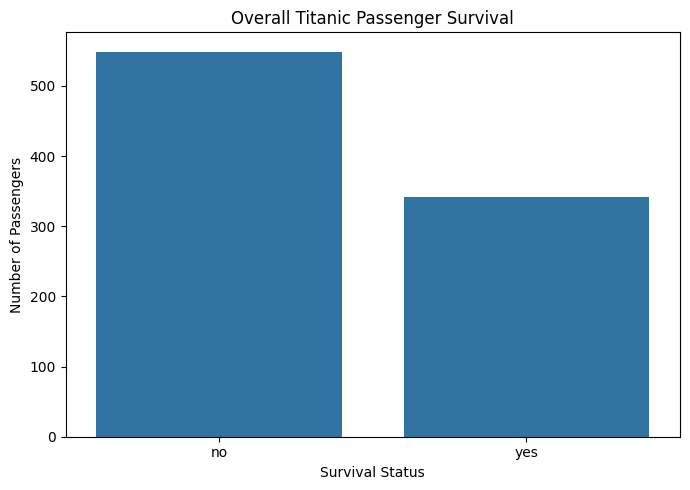

In [5]:
# Overall survival analysis
survival_counts = titanic["survived"].value_counts().sort_index()
survival_rate = titanic["survived"].mean() * 100

print("OVERALL SURVIVAL ANALYSIS")
print("=" * 40)
print(f"Total Passengers : {len(titanic)}")
print(f"Did Not Survive  : {survival_counts[0]}")
print(f"Survived         : {survival_counts[1]}")
print(f"Overall Survival Rate: {survival_rate:.2f}%")

# Visualization
plt.figure(figsize=(7, 5))

sns.countplot(
    data=titanic,
    x="alive"
)

plt.title("Overall Titanic Passenger Survival")
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.show()

SURVIVAL ANALYSIS BY SEX
   Sex  Total Passengers  Survived  Survival Rate
female               314       233          74.20
  male               577       109          18.89


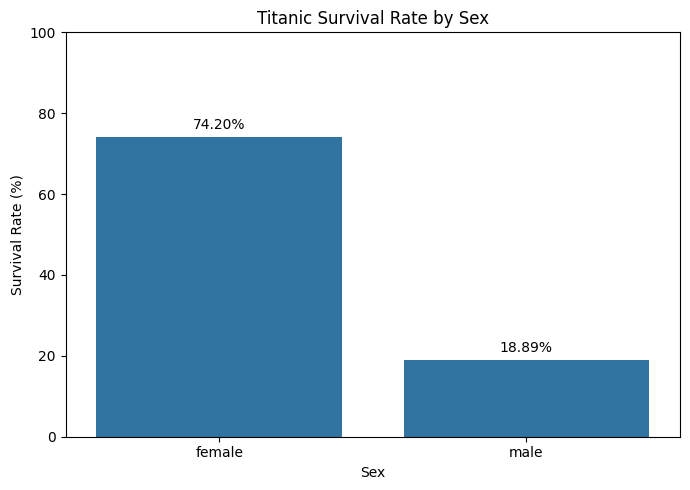

In [6]:
# Survival analysis by sex
sex_survival = (
    titanic.groupby("sex", observed=True)["survived"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

sex_survival.columns = ["Sex", "Total Passengers", "Survived", "Survival Rate"]
sex_survival["Survival Rate"] = (sex_survival["Survival Rate"] * 100).round(2)

print("SURVIVAL ANALYSIS BY SEX")
print("=" * 50)
print(sex_survival.to_string(index=False))

# Visualization
plt.figure(figsize=(7, 5))

sns.barplot(
    data=sex_survival,
    x="Sex",
    y="Survival Rate"
)

plt.title("Titanic Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)

# Add percentage labels
for i, value in enumerate(sex_survival["Survival Rate"]):
    plt.text(i, value + 2, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.show()

SURVIVAL ANALYSIS BY PASSENGER CLASS
 Passenger Class  Total Passengers  Survived  Survival Rate
               1               216       136          62.96
               2               184        87          47.28
               3               491       119          24.24


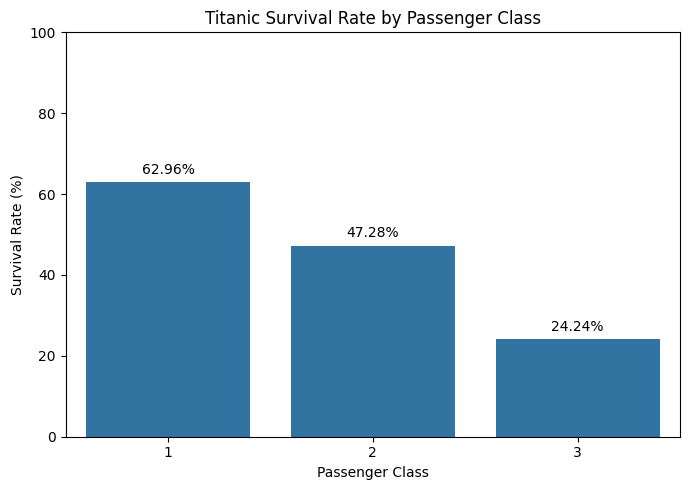

In [7]:
# Survival analysis by passenger class
class_survival = (
    titanic.groupby("pclass")["survived"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

class_survival.columns = [
    "Passenger Class",
    "Total Passengers",
    "Survived",
    "Survival Rate"
]

class_survival["Survival Rate"] = (
    class_survival["Survival Rate"] * 100
).round(2)

print("SURVIVAL ANALYSIS BY PASSENGER CLASS")
print("=" * 55)
print(class_survival.to_string(index=False))

# Visualization
plt.figure(figsize=(7, 5))

sns.barplot(
    data=class_survival,
    x="Passenger Class",
    y="Survival Rate"
)

plt.title("Titanic Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)

# Percentage labels
for i, value in enumerate(class_survival["Survival Rate"]):
    plt.text(i, value + 2, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.show()

SURVIVAL ANALYSIS BY AGE GROUP
          Age Group  Total Passengers  Survived  Survival Rate
       Child (0-12)                69        40          57.97
       Teen (13-18)                70        30          42.86
Young Adult (19-30)               447       148          33.11
      Adult (31-45)               202        86          42.57
 Middle Age (46-60)                81        33          40.74
       Senior (60+)                22         5          22.73


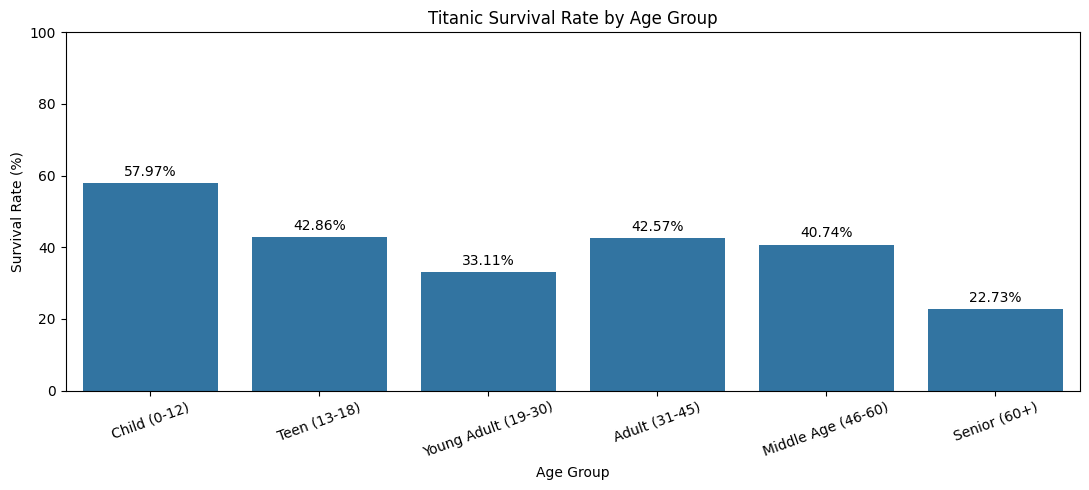

In [8]:
# Create age groups
age_bins = [0, 12, 18, 30, 45, 60, 100]
age_labels = [
    "Child (0-12)",
    "Teen (13-18)",
    "Young Adult (19-30)",
    "Adult (31-45)",
    "Middle Age (46-60)",
    "Senior (60+)"
]

titanic["age_group"] = pd.cut(
    titanic["age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

# Survival analysis by age group
age_survival = (
    titanic.groupby("age_group", observed=True)["survived"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

age_survival.columns = [
    "Age Group",
    "Total Passengers",
    "Survived",
    "Survival Rate"
]

age_survival["Survival Rate"] = (
    age_survival["Survival Rate"] * 100
).round(2)

print("SURVIVAL ANALYSIS BY AGE GROUP")
print("=" * 65)
print(age_survival.to_string(index=False))

# Visualization
plt.figure(figsize=(11, 5))

sns.barplot(
    data=age_survival,
    x="Age Group",
    y="Survival Rate"
)

plt.title("Titanic Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)

for i, value in enumerate(age_survival["Survival Rate"]):
    plt.text(i, value + 2, f"{value:.2f}%", ha="center")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

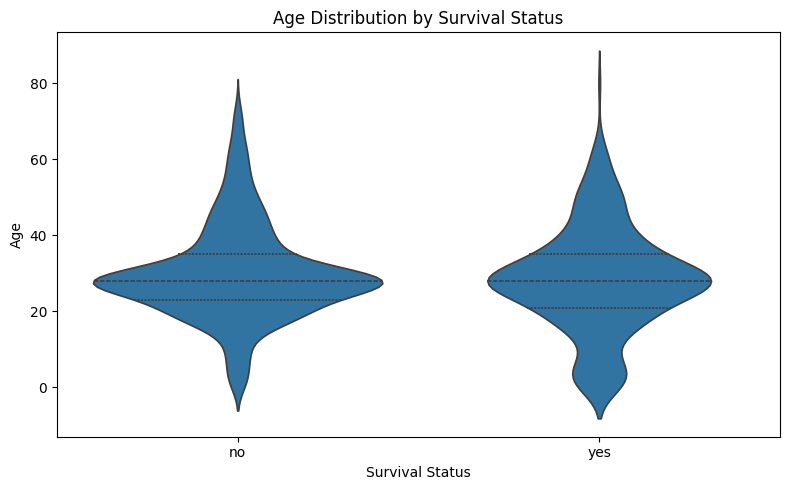

In [9]:
# Violin plot: Age distribution by survival status

plt.figure(figsize=(8, 5))

sns.violinplot(
    data=titanic,
    x="alive",
    y="age",
    inner="quartile"
)

plt.title("Age Distribution by Survival Status")
plt.xlabel("Survival Status")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

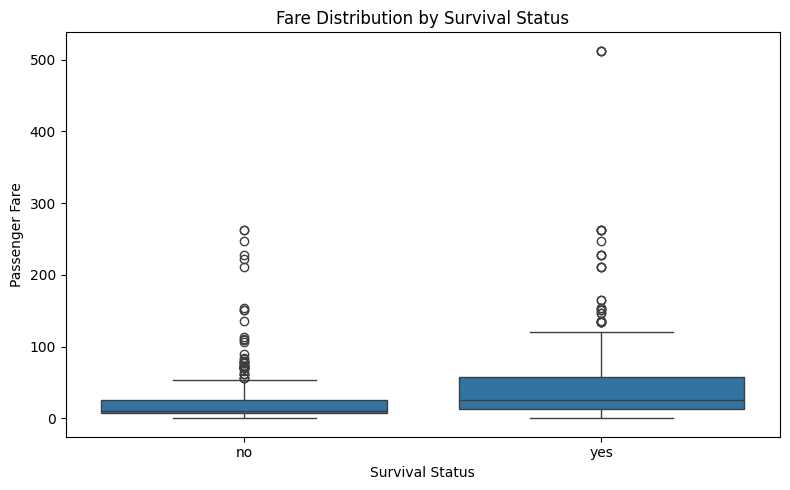

In [10]:
# Boxplot: Fare distribution by survival status

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=titanic,
    x="alive",
    y="fare"
)

plt.title("Fare Distribution by Survival Status")
plt.xlabel("Survival Status")
plt.ylabel("Passenger Fare")

plt.tight_layout()
plt.show()

SURVIVAL RATE BY SEX AND PASSENGER CLASS
 Passenger Class    Sex  Survival Rate
               1 female          96.81
               1   male          36.89
               2 female          92.11
               2   male          15.74
               3 female          50.00
               3   male          13.54


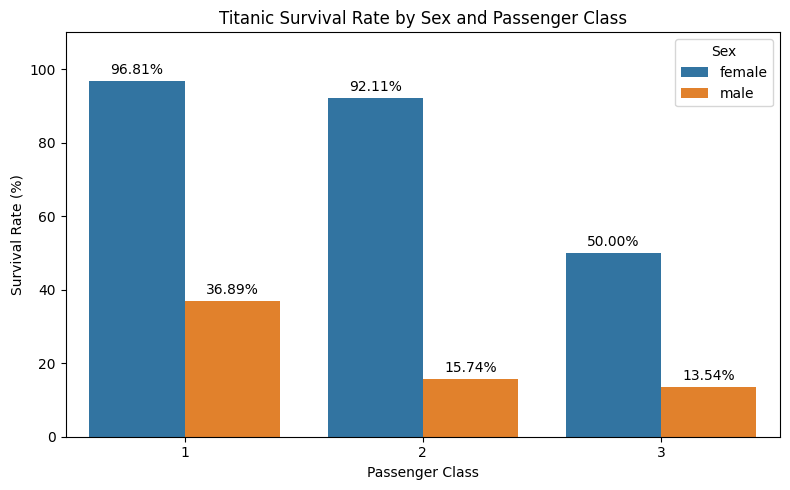

In [11]:
# Survival rate by sex and passenger class
sex_class_survival = (
    titanic.groupby(["pclass", "sex"], observed=True)["survived"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
)

sex_class_survival.columns = [
    "Passenger Class",
    "Sex",
    "Survival Rate"
]

print("SURVIVAL RATE BY SEX AND PASSENGER CLASS")
print("=" * 55)
print(sex_class_survival.to_string(index=False))

# Visualization
plt.figure(figsize=(8, 5))

sns.barplot(
    data=sex_class_survival,
    x="Passenger Class",
    y="Survival Rate",
    hue="Sex"
)

plt.title("Titanic Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 110)

# Add percentage labels
for container in plt.gca().containers:
    plt.gca().bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.legend(title="Sex")
plt.tight_layout()
plt.show()

## 📌 Key Insights

1. **Overall Survival:** Out of 891 passengers, 342 survived, resulting in an overall survival rate of **38.38%**.

2. **Sex and Survival:** Female passengers had a substantially higher survival rate (**74.20%**) than male passengers (**18.89%**), indicating a strong association between sex and survival.

3. **Passenger Class:** Survival decreased with passenger class. First-class passengers had the highest survival rate (**62.96%**), followed by second class (**47.28%**) and third class (**24.24%**).

4. **Age Groups:** Children aged 0–12 had the highest survival rate among the analyzed age groups (**57.97%**), while passengers above 60 had the lowest (**22.73%**).

5. **Combined Sex and Class Pattern:** Female passengers maintained higher survival rates across all three classes. First-class females had the highest observed survival rate (**96.81%**), whereas third-class males had one of the lowest (**13.54%**).

## 🎯 Conclusion

This exploratory data analysis examined survival patterns among Titanic passengers using demographic and travel-related characteristics. The analysis found substantial differences in survival across **sex, passenger class, and age groups**.

Female passengers showed considerably higher survival rates than male passengers, while first-class passengers had higher survival rates than those travelling in second and third class. Children also demonstrated a relatively high survival rate, whereas passengers above 60 had the lowest survival rate among the analyzed age groups.

The combined analysis of sex and passenger class further showed that female passengers maintained higher survival rates across all three classes. Overall, the EDA demonstrates how exploratory analysis and visualization can reveal meaningful patterns and associations within passenger data.

> **Note:** The findings represent descriptive associations observed in the dataset and should not be interpreted as proof of causation.